# Experiment 4.1 — Characterising Feature Extractors

Position-only ICP has a narrow basin of attraction. Per-point
*descriptors* promise a wider one: if a point's descriptor is the same in both clouds, its
correspondent can be found at any misalignment. For that, a descriptor has to be

| § | Property | Question |
|---|---|---|
| 2 | **Invariance** | Is it unchanged by the rigid transformation being recovered? |
| 3 | **Redundancy** | How many independent numbers does it actually carry? |
| 4 | **Robustness** | Do a true pair's descriptors still agree under noise and dropout? |
| 5 | **Discriminative power** | Is the true correspondent closer than every impostor? |

§1 motivates the list with the ideal descriptor. §2–3 measure clean clouds, §4–5 degraded
ones, all in descriptor space without running ICP. How descriptors enter ICP is notebook 4.2.

In [1]:
import sys
sys.path.insert(0, '../src')

from typing import Any, Literal

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.axes import Axes
from matplotlib.image import AxesImage
from scipy.stats import spearmanr
from sklearn.decomposition import PCA
from tabulate import tabulate
from tqdm import tqdm

from error_metrics import (
    correspondence_margin,
    feature_correspondence_correlation,
    mutual_nearest_neighbor_fraction,
)
from experiment_runner import MultiSeedSyntheticICPResult, fit_multi_seed
from feature_extractor import (
    FeatureExtractor,
    GeometricFeatureExtractor,
    IdentityFeatureExtractor,
    RobustGeometricFeatureExtractor,
    zscored_features,
)
from icp import ICP, SigmaAnnealingCallback
from matcher import GaussianMatcher, NearestNeighborMatcher
from point_cloud import PointCloud
from synthetic import (
    CloudStyle,
    PerfectObserver,
    SyntheticExperiment,
    invert_correspondence,
    make_correspondence_pair,
)
from transformation import RigidTransformation
from visualization import SweepVisualizer

plt.style.use('seaborn-v0_8-whitegrid')

CLOUD_STYLE: CloudStyle = 'clustered'
ALL_STYLES: list[CloudStyle] = ['random', 'clustered', 'lattice', '2d-lattice', 'muscle-fiber']

# §1 runs ICP with the oracle descriptor, np.eye(N): memory grows quadratically with N.
ORACLE_GEN_KWARGS: dict[str, Any] = dict(n=200, t_scale=8.0, style=CLOUD_STYLE)
ORACLE_SEEDS = list(range(20))
MAX_ITER, TOL = 400, 1e-6
SIGMA_INIT, SIGMA_FINAL = 20.0, 1.0
MATCHER_K = 10   # candidates the Gaussian matcher averages over
BETA = 3.0       # feature weight, chosen in notebook 4.2

# §2-5 characterise descriptors directly. Clouds are normalised to a point spacing of 1,
# so noise levels below are in units of point spacing.
CHAR_GEN_KWARGS: dict[str, Any] = dict(n=2000, t_scale=8.0, style=CLOUD_STYLE)
CHAR_SEEDS = [0, 1, 2]
FE_K = 40                          # neighbourhood size where one k is enough (§2-3)
K_VALUES = [10, 20, 40, 80, 160]   # neighbourhood sizes swept in §4-5

EXTRACTOR_FACTORIES: dict[str, type[FeatureExtractor]] = {
    'Geometric': GeometricFeatureExtractor,
    'Robust': RobustGeometricFeatureExtractor,
}

## 1. The ideal descriptor

`IdentityFeatureExtractor` gives point *i* the one-hot vector *eᵢ*. It has every property on
the list: it is exactly invariant, its dimensions are independent, and a true pair is at
distance 0 while every impostor is at √2. It is also unusable in practice — it presumes the
correspondence it is meant to find and does not survive dropout. As a ceiling, it shows what
descriptors can buy at best.

In [2]:
def build_icp(matcher_kind: Literal['soft', 'hard'], extractor: FeatureExtractor | None) -> ICP:
    """Instantiate ICP with a soft or hard matcher, with or without appended features.

    Args:
        matcher_kind: 'soft' for Gaussian matching with sigma annealing, 'hard' for
                      nearest-neighbour matching.
        extractor:    Feature extractor appended to positions, or None for positions only.

    Returns:
        A configured ICP.
    """
    feature_kwargs: dict[str, Any] = (
        {} if extractor is None else {'feature_extractor': extractor, 'beta': BETA}
    )
    if matcher_kind == 'hard':
        return ICP(matcher=NearestNeighborMatcher(**feature_kwargs), max_iter=MAX_ITER, tol=TOL)
    if extractor is not None:
        feature_kwargs['feature_mode'] = 'append'
    return ICP(
        matcher=GaussianMatcher(sigma=SIGMA_INIT, k=MATCHER_K, **feature_kwargs),
        max_iter=MAX_ITER, tol=TOL,
        callbacks=[SigmaAnnealingCallback(SIGMA_INIT, SIGMA_FINAL, MAX_ITER)],
    )


def summarise(results: dict[str, MultiSeedSyntheticICPResult], tol: float) -> str:
    """Tabulate reliability, iterations and runtime per variant.

    Args:
        results: Variant label -> multi-seed result.
        tol:     Mean true residual below which a seed counts as recovered.

    Returns:
        A rendered table, most reliable variant first.
    """
    rows = []
    for label, result in results.items():
        ok = np.array(result.mean_true_residuals) < tol
        iterations = [r.n_iterations for r, keep in zip(result.results, ok) if keep]
        rows.append((label, ok.mean(), np.median(iterations) if iterations else np.nan,
                     np.median(result.durations_s)))
    rows.sort(key=lambda row: -row[1])
    return tabulate(
        rows, headers=['Variant', 'Reliability', 'Iters (successful)', 'Runtime (s)'],
        floatfmt=('', '.0%', '.0f', '.2f'), tablefmt='rounded_outline',
    )


ORACLE_VARIANTS: dict[str, tuple[Literal['soft', 'hard'], FeatureExtractor | None]] = {
    'Soft | baseline': ('soft', None),
    'Soft | perfect features': ('soft', IdentityFeatureExtractor()),
    'Hard | baseline': ('hard', None),
    'Hard | perfect features': ('hard', IdentityFeatureExtractor()),
}
results_oracle = {
    label: fit_multi_seed(build_icp(kind, extractor), ORACLE_SEEDS,
                          experiment_kwargs=ORACLE_GEN_KWARGS, observer=PerfectObserver(),
                          verbose=False)
    for label, (kind, extractor) in tqdm(ORACLE_VARIANTS.items(), desc='oracle')
}
print(summarise(results_oracle, tol=1e-3))  # noiseless runs converge to ~1e-5

oracle: 100%|██████████| 4/4 [00:22<00:00,  5.57s/it]

╭─────────────────────────┬───────────────┬──────────────────────┬───────────────╮
│ Variant                 │   Reliability │   Iters (successful) │   Runtime (s) │
├─────────────────────────┼───────────────┼──────────────────────┼───────────────┤
│ Soft | perfect features │          100% │                  109 │          0.58 │
│ Hard | perfect features │          100% │                   11 │          0.04 │
│ Hard | baseline         │           20% │                   24 │          0.01 │
│ Soft | baseline         │            0% │                  nan │          0.51 │
╰─────────────────────────┴───────────────┴──────────────────────┴───────────────╯


### Observations

- **Perfect features make the problem trivial.** Every seed is recovered; without features ICP
  only succeeds when the random initialisation happens to start in the correct basin.
- **They also make the soft matcher unnecessary.** Plain nearest-neighbour matching is as
  reliable and the fastest variant: sigma annealing copes with bad correspondences, and none
  are left. Notebooks 4.2 and 4.3 therefore use hard matching.

A real descriptor cannot presume the correspondence, so the question becomes how close it gets
to each of the ideal's properties.

# Geometric and Robust Feature Extractors
Both candidates describe a point by its `k` nearest neighbours — distance statistics, the
shape of the local covariance (eigenvalue ratios), neighbour angles, and the point's offset
from the neighbour centroid. `Robust` replaces single-value statistics with quantiles and
centres the covariance on the neighbour centroid instead of the query point.

In [3]:
from itertools import zip_longest

names = {name: factory(k=FE_K).feature_names for name, factory in EXTRACTOR_FACTORIES.items()}
print(tabulate(
    zip_longest(*names.values(), fillvalue=''),
    headers=list(names), tablefmt='rounded_outline',
))

╭─────────────────┬─────────────────╮
│ Geometric       │ Robust          │
├─────────────────┼─────────────────┤
│ dist_min        │ dist_q25%       │
│ dist_cv         │ dist_q50%       │
│ centroid_offset │ dist_q75%       │
│ linearity       │ centroid_offset │
│ sphericity      │ linearity       │
│ angle_mean      │ sphericity      │
│ angle_std       │ angle_q25%      │
│                 │ angle_q50%      │
│                 │ angle_q75%      │
╰─────────────────┴─────────────────╯


## 2. Invariance

Each cloud is moved by random rigid transformations and its descriptor recomputed. An invariant
descriptor gives a mean absolute error (MAE) at floating-point zero. All cloud styles are
included here; the rest of the notebook uses `clustered`.

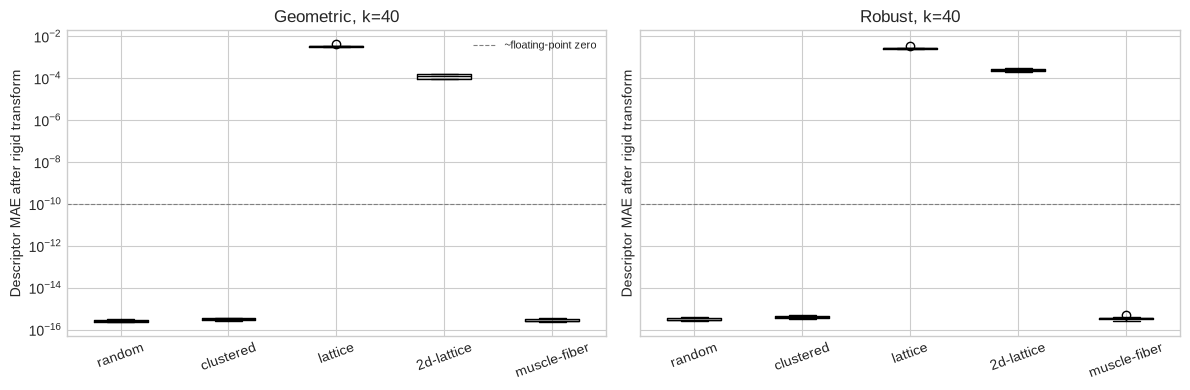

In [4]:
N_TRANSFORMS = 3


def invariance_errors(extractor: FeatureExtractor, style: CloudStyle) -> np.ndarray:
    """MAE between the descriptors of a cloud and of rigidly transformed copies of it.

    Args:
        extractor: Feature extractor to check.
        style:     Cloud style to generate.

    Returns:
        (len(CHAR_SEEDS) * N_TRANSFORMS,) array, one MAE per (seed, transformation).
    """
    errors = []
    for seed in CHAR_SEEDS:
        cloud = SyntheticExperiment.generate(**CHAR_GEN_KWARGS | {'style': style}, seed=seed).S
        features = extractor.get_features(cloud)
        np.random.seed(1000 + seed)  # RigidTransformation.random draws from the global generator
        for _ in range(N_TRANSFORMS):
            moved = RigidTransformation.random(t_scale=10.0).apply(cloud)
            errors.append(np.abs(features - extractor.get_features(moved)).mean())
    return np.array(errors)


fig, axes = plt.subplots(1, len(EXTRACTOR_FACTORIES), figsize=(12, 4), sharey=True)
for ax, (name, factory) in zip(axes, EXTRACTOR_FACTORIES.items()):
    extractor = factory(k=FE_K)
    ax.boxplot([invariance_errors(extractor, style) for style in ALL_STYLES],
               tick_labels=ALL_STYLES, medianprops=dict(color='black'))
    ax.axhline(1e-10, color='grey', linestyle='--', linewidth=0.8, label='~floating-point zero')
    ax.set(yscale='log', title=f'{name}, k={FE_K}', ylabel='Descriptor MAE after rigid transform')
    ax.tick_params(axis='x', rotation=20)
axes[0].legend(fontsize=8)
fig.tight_layout()
fig.savefig('../results/4_1_invariance.png', dpi=150, bbox_inches='tight')
plt.show()

### Observations

- **Exact on irregular clouds.** On `random`, `clustered` and `muscle-fiber` both extractors
  are invariant to floating-point precision.
- **Broken on perfect lattices, by ties.** Every point that changes has its `k`-th and
  `(k+1)`-th neighbour at the same distance; which one the kNN query keeps then depends on
  rounding after the transform, so the neighbourhood itself changes..

## 3. Redundancy

Descriptors are z-scored and all dimensions weighted equally, so two dimensions that measure
the same thing count that signal twice. Measured on clean `clustered` clouds: pairwise Spearman
correlation, and the number of principal components needed for 90% of the variance.

The standard shape set {linearity, planarity, sphericity, anisotropy} has already been pruned
to its first and third member: it has rank 2, since anisotropy = 1 − sphericity and
planarity = 1 − linearity − sphericity.

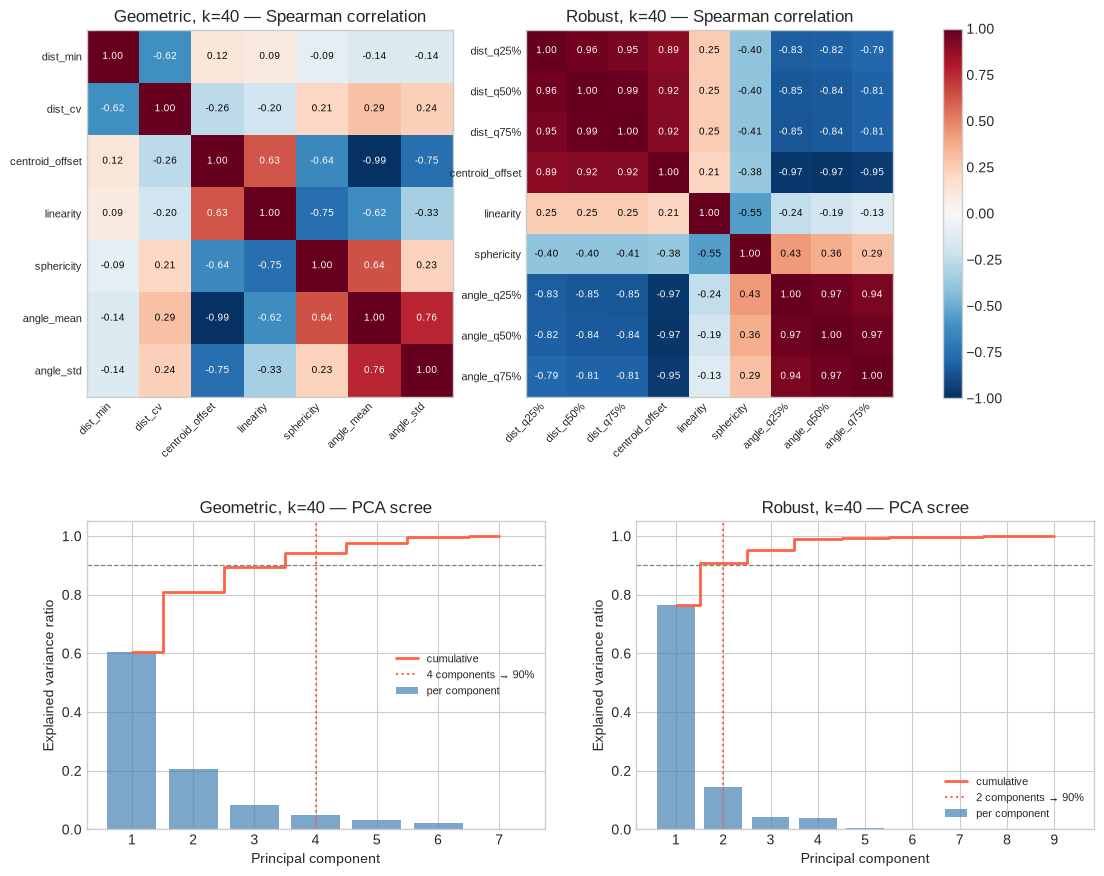

In [5]:
def clean_zscored_features(extractor: FeatureExtractor) -> np.ndarray:
    """Jointly z-scored descriptors of the clean clouds of every CHAR_SEEDS seed.

    Args:
        extractor: Feature extractor to apply.

    Returns:
        (sum of cloud sizes, D) array.
    """
    clouds = [SyntheticExperiment.generate(**CHAR_GEN_KWARGS, seed=seed).P for seed in CHAR_SEEDS]
    return np.concatenate(zscored_features(extractor, clouds))


def plot_correlation(ax: Axes, features: np.ndarray, names: list[str]) -> AxesImage:
    """Draw the annotated Spearman correlation matrix of the descriptor dimensions.

    Args:
        ax:       Axes to draw on.
        features: (N, D) descriptors.
        names:    D dimension names.

    Returns:
        The heatmap image, for a colorbar.
    """
    corr = spearmanr(features).statistic
    image = ax.imshow(corr, vmin=-1, vmax=1, cmap='RdBu_r')
    ax.set_xticks(range(len(names)), names, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(len(names)), names, fontsize=8)
    for i, j in np.ndindex(corr.shape):
        ax.text(j, i, f'{corr[i, j]:.2f}', ha='center', va='center', fontsize=7,
                color='white' if abs(corr[i, j]) > 0.6 else 'black')
    ax.grid(False)
    return image


def plot_scree(ax: Axes, features: np.ndarray) -> None:
    """Draw per-component and cumulative explained variance, marking the 90% point.

    Args:
        ax:       Axes to draw on.
        features: (N, D) descriptors.
    """
    ratios = PCA().fit(features).explained_variance_ratio_
    cumulative = np.cumsum(ratios)
    n90 = int(np.searchsorted(cumulative, 0.90)) + 1
    components = np.arange(1, len(ratios) + 1)
    ax.bar(components, ratios, color='steelblue', alpha=0.7, label='per component')
    ax.step(components, cumulative, where='mid', color='tomato', linewidth=2, label='cumulative')
    ax.axhline(0.90, color='grey', linestyle='--', linewidth=0.9)
    ax.axvline(n90, color='tomato', linestyle=':', label=f'{n90} components → 90%')
    ax.set(xticks=components, xlabel='Principal component', ylabel='Explained variance ratio')
    ax.legend(fontsize=8)


fig, axes = plt.subplots(2, len(EXTRACTOR_FACTORIES), figsize=(13, 11),
                         gridspec_kw=dict(height_ratios=[1.5, 1]))
for col, (name, factory) in enumerate(EXTRACTOR_FACTORIES.items()):
    extractor = factory(k=FE_K)
    features = clean_zscored_features(extractor)
    image = plot_correlation(axes[0, col], features, extractor.feature_names)
    axes[0, col].set_title(f'{name}, k={FE_K} — Spearman correlation')
    plot_scree(axes[1, col], features)
    axes[1, col].set_title(f'{name}, k={FE_K} — PCA scree')
fig.colorbar(image, ax=axes[0, :].tolist(), shrink=0.8)
fig.savefig('../results/4_1_redundancy.png', dpi=150, bbox_inches='tight')
plt.show()

### Observations

- **`Geometric` is mostly non-redundant.** One near-duplicate pair (`centroid_offset` and
  `angle_mean`); otherwise the dimensions measure different things, and about four components
  carry 90% of the variance.
- **`Robust` is highly redundant.** Each quantile triple is nearly three copies of one
  number, and the distance quantiles, angle quantiles and `centroid_offset` all move along one
  shared axis. Its nine dimensions carry about two independent directions — fewer than
  `Geometric`'s seven — and equal weighting counts that dominant axis many times over.
- `Geometric`'s `linearity` correlates with `centroid_offset`, `Robust`'s does not. §4 explains
  why and what it costs.

## 4. Robustness

Source and target are observed independently, so under noise or dropout a surviving point's
descriptor is computed from a different neighbourhood on each side.
`feature_correspondence_correlation` measures, per dimension, how well true pairs still agree —
correlation rather than absolute error, because z-scoring discards scale and offset anyway. By
§2 every dimension correlates at exactly 1.0 on clean `clustered` clouds, so any drop is caused
by the perturbation.

Two summaries per configuration: the **mean** over dimensions, and the **weakest** dimension —
with equal weights, one dead dimension adds noise to every distance.

Robust / dropout_prob: 100%|██████████| 5/5 [00:15<00:00,  3.08s/it]


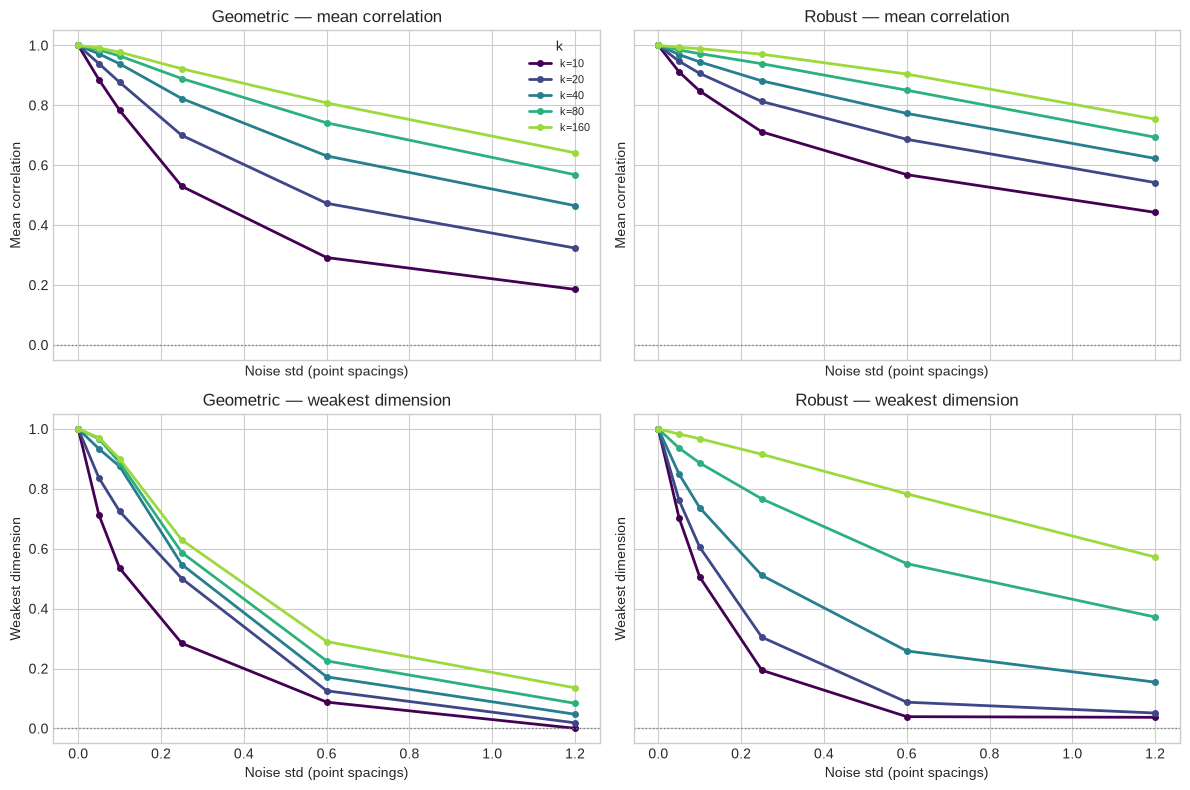

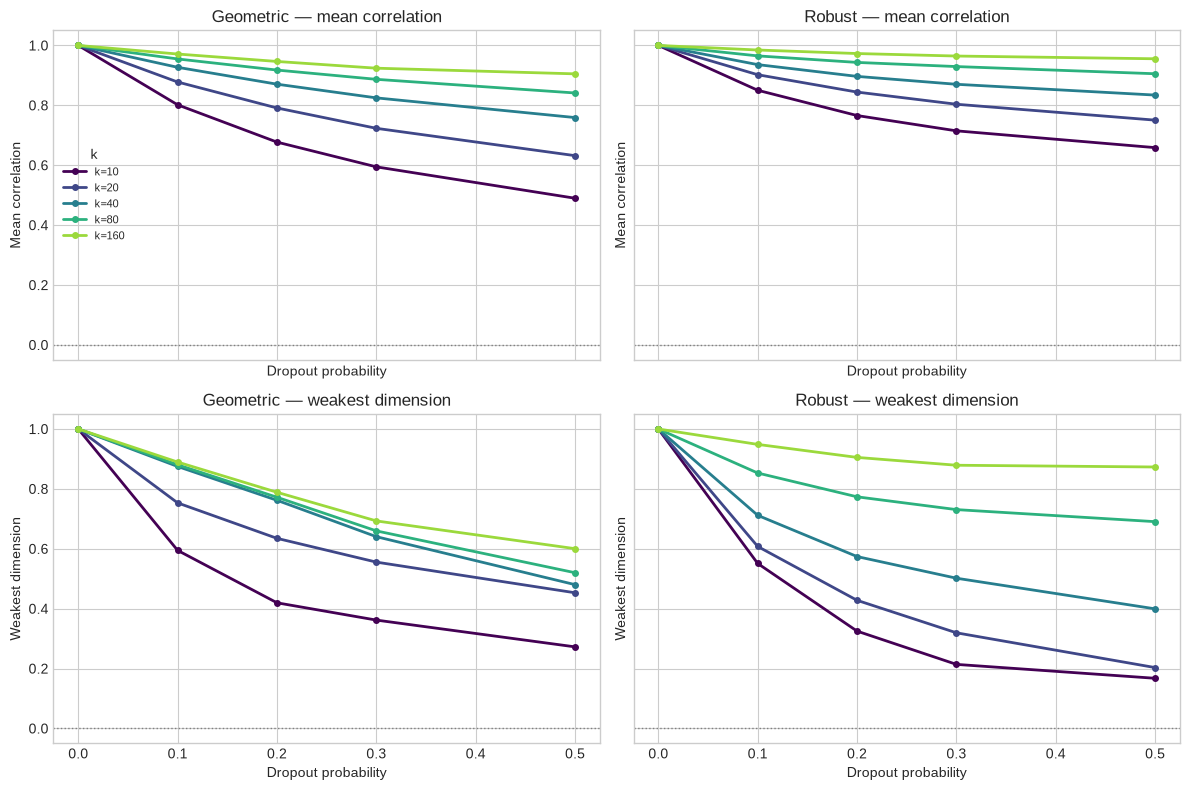

In [6]:
NOISE_LEVELS = [0.0, 0.05, 0.1, 0.25, 0.6, 1.2]
DROPOUT_LEVELS = [0.0, 0.1, 0.2, 0.3, 0.5]


def perturbed_pair(
    seed: int, noise_std: float, dropout_prob: float,
) -> tuple[PointCloud, PointCloud, np.ndarray]:
    """Two independently degraded observations of one clean cloud pair.

    Args:
        seed:         Experiment seed.
        noise_std:    Std of the Gaussian noise applied to each side independently.
        dropout_prob: Per-point probability of dropping a point on each side.

    Returns:
        Tuple (source, target, target_to_source), the last mapping each target point to its
        source correspondent, or -1 if that was dropped.
    """
    experiment = SyntheticExperiment.generate(**CHAR_GEN_KWARGS, seed=seed)
    return make_correspondence_pair(
        experiment.P, experiment.Q, dropout_prob=dropout_prob,
        noise_std=noise_std, rng=np.random.default_rng(seed),
    )


def per_dimension_correlations(
    extractor: FeatureExtractor, noise_std: float = 0.0, dropout_prob: float = 0.0,
) -> np.ndarray:
    """Correlation of each descriptor dimension across surviving true pairs.

    Args:
        extractor:    Feature extractor to characterise.
        noise_std:    Std of the Gaussian noise applied to each side independently.
        dropout_prob: Per-point probability of dropping a point on each side.

    Returns:
        (D,) correlations aligned with ``extractor.feature_names``, averaged over CHAR_SEEDS.
    """
    per_seed = []
    for seed in CHAR_SEEDS:
        source, target, target_to_source = perturbed_pair(seed, noise_std, dropout_prob)
        matched = target_to_source >= 0
        per_seed.append(feature_correspondence_correlation(
            extractor.get_features(source)[target_to_source[matched]],
            extractor.get_features(target)[matched],
        ))
    return np.mean(per_seed, axis=0)


def sweep_robustness(levels: list[float], knob: Literal['noise_std', 'dropout_prob']) -> dict[str, np.ndarray]:
    """Per-dimension correlations over a perturbation sweep, for every extractor and k.

    Args:
        levels: Perturbation strengths.
        knob:   Which perturbation the levels refer to.

    Returns:
        Extractor name -> (len(K_VALUES), len(levels), D) array of correlations.
    """
    return {
        name: np.array([
            [per_dimension_correlations(factory(k=k), **{knob: level}) for level in levels]
            for k in tqdm(K_VALUES, desc=f'{name} / {knob}')
        ])
        for name, factory in EXTRACTOR_FACTORIES.items()
    }


def plot_robustness(correlations: dict[str, np.ndarray], levels: list[float], x_label: str, save_path: str) -> None:
    """Plot the mean and the weakest dimension's correlation over a perturbation sweep.

    Rows are the two summaries, columns the extractors, curves the k values.

    Args:
        correlations: Output of ``sweep_robustness``.
        levels:       Perturbation strengths, the shared x-axis.
        x_label:      Label for that axis.
        save_path:    Where to write the PNG.
    """
    fig, axes = plt.subplots(2, len(correlations), figsize=(12, 8), sharex=True, sharey='row')
    shades = plt.cm.viridis(np.linspace(0.0, 0.85, len(K_VALUES)))
    for col, (name, scores) in enumerate(correlations.items()):
        for row, (summary, reduce) in enumerate([('Mean correlation', np.mean),
                                                  ('Weakest dimension', np.min)]):
            ax = axes[row, col]
            for i, k in enumerate(K_VALUES):
                ax.plot(levels, reduce(scores[i], axis=-1), marker='o', ms=4,
                        color=shades[i], linewidth=2, label=f'k={k}')
            ax.axhline(0.0, color='grey', linewidth=1, linestyle=':')
            ax.set(title=f'{name} — {summary.lower()}', ylabel=summary, xlabel=x_label)
    axes[0, 0].legend(title='k', fontsize=8)
    fig.tight_layout()
    fig.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


robustness = {
    'noise_std': sweep_robustness(NOISE_LEVELS, 'noise_std'),
    'dropout_prob': sweep_robustness(DROPOUT_LEVELS, 'dropout_prob'),
}
plot_robustness(robustness['noise_std'], NOISE_LEVELS, 'Noise std (point spacings)',
                '../results/4_1_robustness_noise.png')
plot_robustness(robustness['dropout_prob'], DROPOUT_LEVELS, 'Dropout probability',
                '../results/4_1_robustness_dropout.png')

### Which features break?

The same measurement per named dimension, at one high level of each perturbation, most
vulnerable first.

In [7]:
TABLE_K = [10, 40, 160]


def per_dimension_table(knob: Literal['noise_std', 'dropout_prob'], level: float, levels: list[float]) -> str:
    """Rank every dimension of every extractor by its correlation at one perturbation level.

    Args:
        knob:   Which perturbation sweep of ``robustness`` to read.
        level:  Perturbation strength, one of ``levels``.
        levels: The levels that sweep was run at.

    Returns:
        A rendered table, most vulnerable first as judged at the middle k.
    """
    j = levels.index(level)
    rows = []
    for name, factory in EXTRACTOR_FACTORIES.items():
        scores = robustness[knob][name]
        for dim, feature in enumerate(factory(k=FE_K).feature_names):
            rows.append([name, feature] + [scores[K_VALUES.index(k), j, dim] for k in TABLE_K])
    rows.sort(key=lambda row: row[2 + len(TABLE_K) // 2])
    return f'{knob} = {level}\n' + tabulate(
        rows, headers=['Extractor', 'Feature'] + [f'k={k}' for k in TABLE_K],
        floatfmt='.3f', tablefmt='rounded_outline',
    )


print(per_dimension_table('noise_std', 0.6, NOISE_LEVELS))
print(per_dimension_table('dropout_prob', 0.3, DROPOUT_LEVELS))

noise_std = 0.6
╭─────────────┬─────────────────┬────────┬────────┬─────────╮
│ Extractor   │ Feature         │   k=10 │   k=40 │   k=160 │
├─────────────┼─────────────────┼────────┼────────┼─────────┤
│ Geometric   │ dist_min        │  0.088 │  0.172 │   0.290 │
│ Robust      │ linearity       │  0.039 │  0.259 │   0.783 │
│ Robust      │ sphericity      │  0.081 │  0.374 │   0.818 │
│ Geometric   │ dist_cv         │  0.146 │  0.436 │   0.848 │
│ Geometric   │ sphericity      │  0.126 │  0.584 │   0.876 │
│ Geometric   │ linearity       │  0.158 │  0.630 │   0.874 │
│ Geometric   │ angle_std       │  0.401 │  0.849 │   0.918 │
│ Geometric   │ centroid_offset │  0.510 │  0.853 │   0.920 │
│ Robust      │ angle_q25%      │  0.449 │  0.870 │   0.922 │
│ Robust      │ angle_q50%      │  0.535 │  0.884 │   0.926 │
│ Robust      │ angle_q75%      │  0.557 │  0.886 │   0.927 │
│ Geometric   │ angle_mean      │  0.614 │  0.894 │   0.931 │
│ Robust      │ dist_q25%       │  0.839 │  0.908 │   

### Observations

- **`k` dominates.** A wider neighbourhood averages the perturbation away, and this effect is
  larger than any difference between the extractors.
- **`Robust` is more robust on average, but its weakest dimension only overtakes
  `Geometric`'s at large `k`.** Quantiles need enough neighbours to be estimated from.
- **Dropout is gentler than noise.** It thins a neighbourhood but leaves the survivors in
  place; noise moves every point at once.
- **`Geometric`'s weak link is `dist_min`.** A single order statistic gains nothing from more
  neighbours, and it changes outright when the nearest neighbour is dropped. `Robust`'s
  distance quantiles fix this and are its most stable features.
- **`Robust`'s weak link is its shape block.** `Geometric` centres the neighbourhood
  covariance on the query point, `Robust` on the neighbour centroid. By the parallel-axis
  theorem the difference is a rank-1 term built from the point's offset within its
  neighbourhood — the stable `centroid_offset` signal, visible in §3 as its correlation with
  `Geometric`'s `linearity`. `Robust` removes it to avoid counting `centroid_offset` twice, and
  pays for that in robustness.
- **High correlation is necessary, not sufficient.** It is maximised by a descriptor that
  carries no information, so it cannot choose `k` on its own. §5 measures the other half.

## 5. Discriminative power

Robustness is maximised by a descriptor that carries no information: at `k → N` every point is
described by the whole cloud and all descriptors are identical. Matching needs a true pair to
be close *relative to every other point*. Two metrics, in descriptor space alone:

- **Mutual nearest-neighbour fraction** — the share of true pairs that are each other's nearest
  neighbour. This is the decision a matcher makes.
- **Median correspondence margin** — d(true correspondent) / d(nearest impostor); below 1 the
  correspondent wins. Unlike the fraction, it does not saturate.

Noise and dropout are applied together here, as a real sensor delivers both. The `clean` column
is only a sanity check: identical clouds give any invariant descriptor a perfect score.

In [8]:
DEGRADATION_LEVELS: dict[str, dict[str, float]] = {
    'clean':     dict(noise_std=0.00, dropout_prob=0.0),
    'very mild': dict(noise_std=0.05, dropout_prob=0.05),
    'mild':      dict(noise_std=0.15, dropout_prob=0.10),
    'moderate':  dict(noise_std=0.30, dropout_prob=0.20),
    'heavy':     dict(noise_std=0.60, dropout_prob=0.30),
    'severe':    dict(noise_std=1.00, dropout_prob=0.40),
}


def descriptor_scores(extractor: FeatureExtractor, noise_std: float, dropout_prob: float) -> tuple[float, float]:
    """Mutual-NN fraction and median margin in descriptor space at one degradation level.

    Args:
        extractor:    Feature extractor to characterise.
        noise_std:    Std of the Gaussian noise applied to each side independently.
        dropout_prob: Per-point probability of dropping a point on each side.

    Returns:
        Tuple (mutual-NN fraction, median correspondence margin), averaged over CHAR_SEEDS.
    """
    fractions, margins = [], []
    for seed in CHAR_SEEDS:
        source, target, target_to_source = perturbed_pair(seed, noise_std, dropout_prob)
        scoring = dict(feature_extractor=extractor, use_positions=False,
                       correspondence=invert_correspondence(target_to_source, len(source.points)))
        fractions.append(mutual_nearest_neighbor_fraction(source, target, **scoring))
        margins.append(np.median(correspondence_margin(source, target, **scoring)))
    return float(np.mean(fractions)), float(np.mean(margins))


# extractor -> (len(K_VALUES), len(DEGRADATION_LEVELS), 2) of [fraction, margin]
descriptor_grid = {
    name: np.array([
        [descriptor_scores(factory(k=k), **level) for level in DEGRADATION_LEVELS.values()]
        for k in tqdm(K_VALUES, desc=f'{name} / k x degradation')
    ])
    for name, factory in EXTRACTOR_FACTORIES.items()
}

Robust / k x degradation: 100%|██████████| 5/5 [00:42<00:00,  8.45s/it]


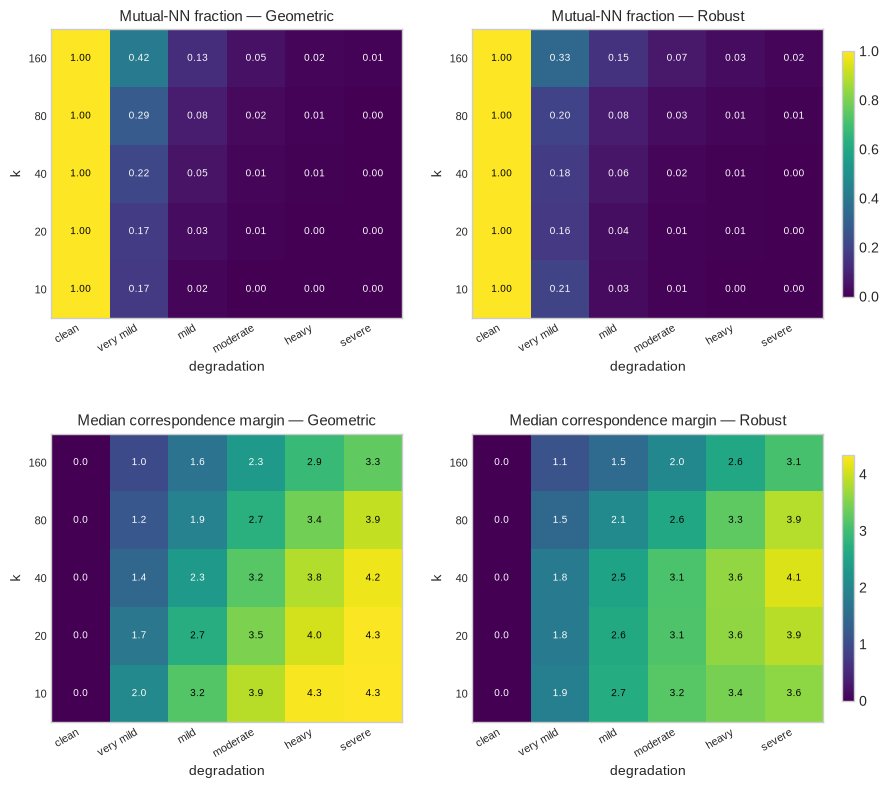

╭───────────────┬──────────────────────────────┬────────────╮
│ degradation   │ best by mutual-NN fraction   │   fraction │
├───────────────┼──────────────────────────────┼────────────┤
│ clean         │ Geometric, k=10              │      1.000 │
│ very mild     │ Geometric, k=160             │      0.415 │
│ mild          │ Robust, k=160                │      0.147 │
│ moderate      │ Robust, k=160                │      0.068 │
│ heavy         │ Robust, k=160                │      0.032 │
│ severe        │ Robust, k=160                │      0.016 │
╰───────────────┴──────────────────────────────┴────────────╯


In [9]:
# Each row shares one colour scale across both extractors, so equal hues mean equal values.
fig, axes = plt.subplots(2, len(EXTRACTOR_FACTORIES), figsize=(12, 9))
fig.subplots_adjust(hspace=0.4)
for row, (metric_label, fmt) in enumerate([('Mutual-NN fraction', '.2f'),
                                           ('Median correspondence margin', '.1f')]):
    shared = np.concatenate([grid[:, :, row].ravel() for grid in descriptor_grid.values()])
    for col, (name, grid) in enumerate(descriptor_grid.items()):
        image = SweepVisualizer.plot_heatmap(
            axes[row, col], grid[:, :, row],
            x_labels=list(DEGRADATION_LEVELS), y_labels=K_VALUES,
            x_label='degradation', y_label='k', title=f'{metric_label} — {name}',
            value_format=fmt, vmin=shared.min(), vmax=shared.max(),
        )
    fig.colorbar(image, ax=axes[row, :].tolist(), shrink=0.85, pad=0.02)
fig.savefig('../results/4_1_descriptor_quality_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()

best = []
for j, level in enumerate(DEGRADATION_LEVELS):
    (name, k), value = max(
        (((name, k), grid[i, j, 0]) for name, grid in descriptor_grid.items()
         for i, k in enumerate(K_VALUES)),
        key=lambda item: item[1],
    )
    best.append([level, f'{name}, k={k}', value])
print(tabulate(best, headers=['degradation', 'best by mutual-NN fraction', 'fraction'],
               floatfmt='.3f', tablefmt='rounded_outline'))

### Observations

- **Descriptors alone cannot match point clouds.** Under any real degradation the typical
  true correspondent is no closer than the nearest impostor. With only a few independent
  dimensions (§3) to tell thousands of points apart, this is expected: descriptors are a second
  signal to combine with position, which is notebook 4.2's subject.
- **Larger `k` helps.** The over-smoothing §4 warns about does not set in up to `k=160`.
- **`Geometric` wins on near-clean data, `Robust` from mild degradation on.** This is the
  redundancy–robustness trade-off of §3–4: `Geometric` carries more independent information
  while it survives, `Robust` keeps less of it but more stably. In ICP (notebook 4.4) the
  difference only appears at small `k`; from `k=80` both are fully reliable.

## Summary

1. **Ideal descriptors solve the problem** (§1): perfect features recover every seed and make
   soft, sigma-annealed matching unnecessary.
2. **Invariance holds** (§2) for both extractors, except for kNN ties on perfectly regular
   lattices.
3. **Redundancy differs sharply** (§3): `Geometric` carries about four independent
   directions, `Robust` about two — its quantiles largely repeat one axis.
4. **Robustness is bought with `k`** (§4). Each extractor has a named weak link:
   `Geometric`'s `dist_min`, `Robust`'s centroid-centred shape features.
5. **Discriminative power is the binding constraint** (§5): descriptors must be combined with
   position rather than replace it. `Robust` at the largest affordable `k` is the better
   choice from mild degradation on, `Geometric` on near-clean data.